In [3]:
# Install scikeras for hyperparameter optimization
!pip install scikeras tensorflow
# Install scikeras with a compatible version of scikit-learn
!pip install "scikit-learn<1.6.0"
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input
from keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
import seaborn as sns

# Configure Matplotlib to strictly use Bold Times New Roman for all elements
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['figure.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
keras.utils.set_random_seed(42)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 45us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original X_train shape: (60000, 28, 28), y_train shape: (60000,)
Original X_test shape: (10000, 28, 28), y_test shape: (10000,)


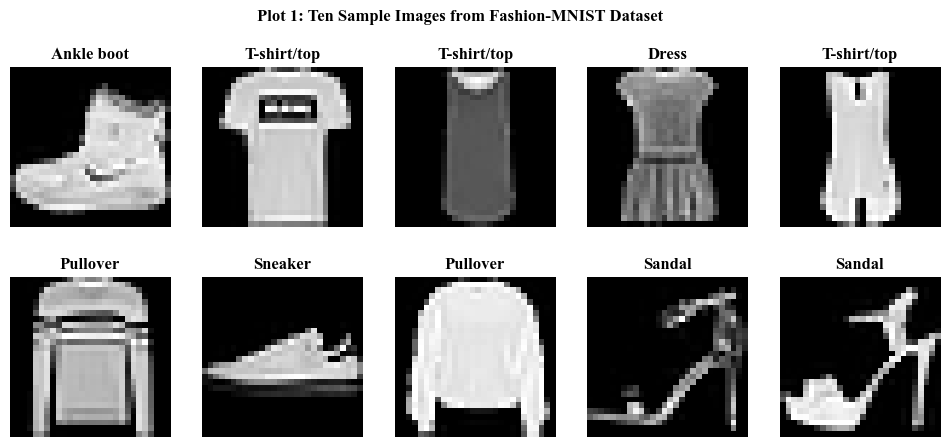

In [4]:
# Load the Fashion-MNIST dataset[cite: 1]
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

# Define class names for plotting
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Print initial dataset dimensions[cite: 1]
print(f"Original X_train shape: {X_train_raw.shape}, y_train shape: {y_train_raw.shape}")
print(f"Original X_test shape: {X_test_raw.shape}, y_test shape: {y_test_raw.shape}")

# Plot 1: Sample Images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Plot 1: Ten Sample Images from Fashion-MNIST Dataset')
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[i], cmap='gray')
    ax.set_title(class_names[y_train_raw[i]], fontweight='bold')
    ax.axis('off')
plt.savefig('plot1_sample_images.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

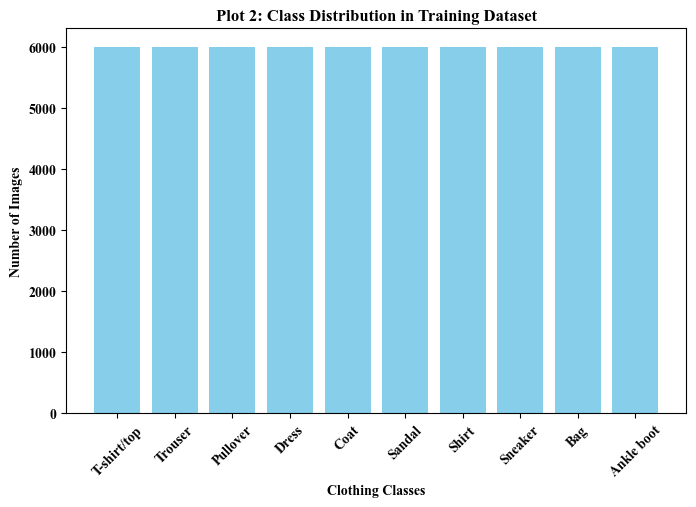

Preprocessed X_train shape: (60000, 784)
Preprocessed y_train shape: (60000, 10)


In [5]:
# Plot 2: Class Distribution
plt.figure(figsize=(8, 5))
unique, counts = np.unique(y_train_raw, return_counts=True)
plt.bar(class_names, counts, color='skyblue')
plt.title('Plot 2: Class Distribution in Training Dataset', fontweight='bold')
plt.xlabel('Clothing Classes', fontweight='bold')
plt.ylabel('Number of Images', fontweight='bold')
plt.xticks(rotation=45, fontweight='bold')
plt.yticks(fontweight='bold')
plt.savefig('plot2_class_distribution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Flatten images to 1D vector of 784 elements and normalize pixels to [0,1][cite: 1]
X_train = X_train_raw.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test_raw.reshape(-1, 784).astype('float32') / 255.0

# Convert labels into one-hot vectors[cite: 1]
y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

# Print tensor shapes after preprocessing[cite: 1]
print(f"Preprocessed X_train shape: {X_train.shape}")
print(f"Preprocessed y_train shape: {y_train.shape}")

In [6]:
# Construct baseline MLP architecture[cite: 1]
baseline_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Display model summary[cite: 1]
baseline_model.summary()

# Compile model using Adam, Categorical Cross Entropy, and Accuracy[cite: 1]
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model with batch size 32 for 20 epochs, using 20% validation split[cite: 1]
history = baseline_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Generate predictions on the test set
y_pred_probs = baseline_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute performance metrics[cite: 1]
acc = accuracy_score(y_test_raw, y_pred)
prec = precision_score(y_test_raw, y_pred, average='weighted')
rec = recall_score(y_test_raw, y_pred, average='weighted')
f1 = f1_score(y_test_raw, y_pred, average='weighted')

print(f"\nBaseline Model Metrics:")
print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test_raw, y_pred, target_names=class_names))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8177 - loss: 0.5109 - val_accuracy: 0.8559 - val_loss: 0.4044
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8640 - loss: 0.3741 - val_accuracy: 0.8605 - val_loss: 0.3786
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8762 - loss: 0.3359 - val_accuracy: 0.8675 - val_loss: 0.3648
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8845 - loss: 0.3099 - val_accuracy: 0.8700 - val_loss: 0.3637
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8918 - loss: 0.2921 - val_accuracy: 0.8671 - val_loss: 0.3730
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8962 - loss: 0.2768 - val_accuracy: 0.8686 - val_loss: 0.3766
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9011 - loss: 0.2615 - val_accuracy: 0.8724 - val_loss: 0.3653
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9054 - loss: 0.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


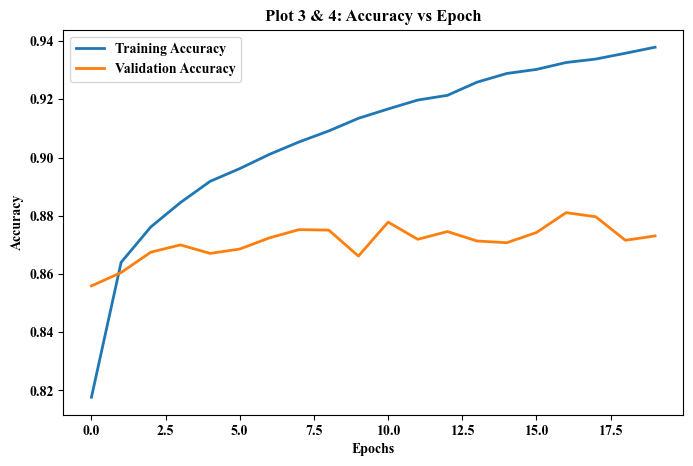

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


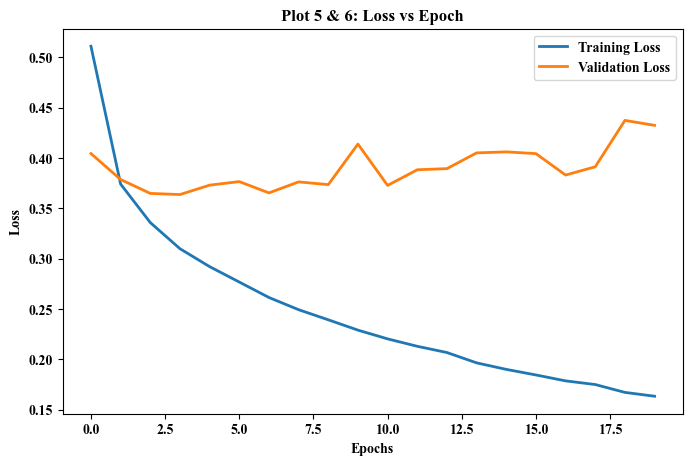

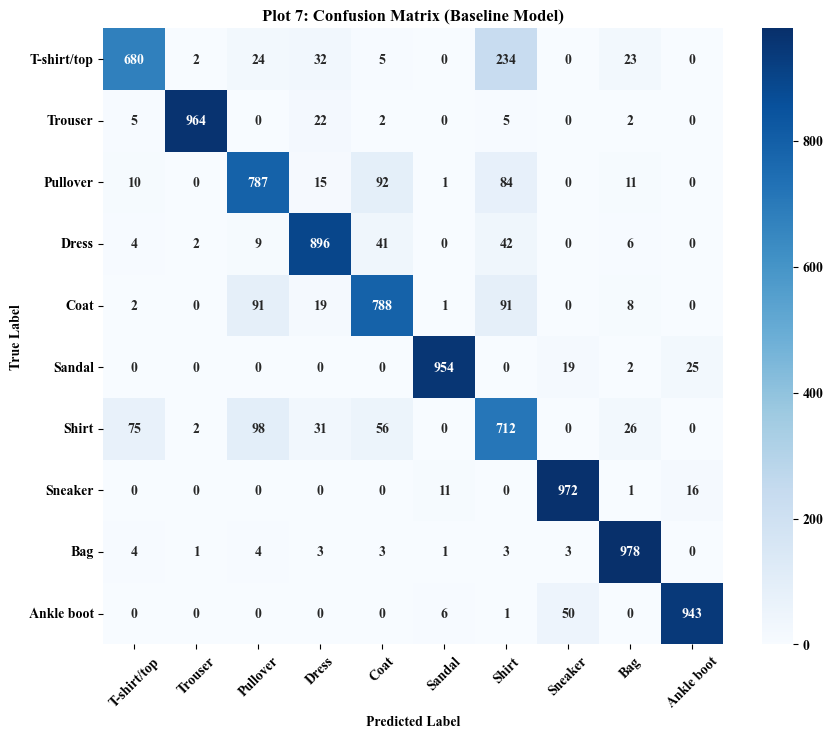

In [7]:
# Helper function to plot and save history metrics
def plot_metric(train_metric, val_metric, metric_name, plot_num, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(train_metric, label=f'Training {metric_name}', linewidth=2)
    plt.plot(val_metric, label=f'Validation {metric_name}', linewidth=2)
    plt.title(f'Plot {plot_num}: {metric_name} vs Epoch', fontweight='bold')
    plt.xlabel('Epochs', fontweight='bold')
    plt.ylabel(metric_name, fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    legend = plt.legend()
    for text in legend.get_texts():
        text.set_weight('bold')
    plt.savefig(filename, format='eps', dpi=600, bbox_inches='tight')
    plt.show()

# Plot 3 & 4: Accuracy Curves
plot_metric(history.history['accuracy'], history.history['val_accuracy'], 'Accuracy', '3 & 4', 'plot3_4_accuracy.eps')

# Plot 5 & 6: Loss Curves
plot_metric(history.history['loss'], history.history['val_loss'], 'Loss', '5 & 6', 'plot5_6_loss.eps')

# Plot 7: Confusion Matrix[cite: 1]
cm = confusion_matrix(y_test_raw, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={'weight': 'bold'})
plt.title('Plot 7: Confusion Matrix (Baseline Model)', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.xticks(rotation=45, fontweight='bold')
plt.yticks(rotation=0, fontweight='bold')
plt.savefig('plot7_confusion_matrix.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

In [8]:
# Define function to build dynamic Keras models for SciKeras
def build_model(hidden_layers=1, hidden_neurons=64, learning_rate=0.01, activation_function='relu', dropout_rate=0.0, optimizer_name='adam'):
    model = Sequential()
    model.add(Input(shape=(784,)))

    # Dynamically add hidden layers based on hyperparameters[cite: 1]
    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation_function))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))

    # Add output layer
    model.add(Dense(10, activation='softmax'))

    # Configure optimizer dynamically[cite: 1]
    if optimizer_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap model with KerasClassifier
keras_clf = KerasClassifier(
    model=build_model,
    hidden_layers=1, hidden_neurons=64, learning_rate=0.01, activation_function='relu', dropout_rate=0.0, optimizer_name='adam',
    epochs=10, batch_size=32, verbose=0
)

# Define search space corresponding to the lab manual[cite: 1]
param_dist = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'activation_function': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5]
}

# Perform Randomized Search sequentially to avoid TensorFlow threading deadlocks
random_search = RandomizedSearchCV(estimator=keras_clf, param_distributions=param_dist, n_iter=5, cv=5, n_jobs=1, verbose=2, random_state=42)
random_search_result = random_search.fit(X_train, y_train)

# Output best
print(f"Best cross-validation accuracy: {random_search_result.best_score_:.4f}")
print("Best hyperparameters selected:")
print(random_search_result.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END activation_function=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=  41.4s
[CV] END activation_function=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time= 1.1min
[CV] END activation_function=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time= 1.3min
[CV] END activation_function=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time= 1.0min
[CV] END activation_function=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time= 1.1min
[CV] END activation_function=relu, batch_size=16, 

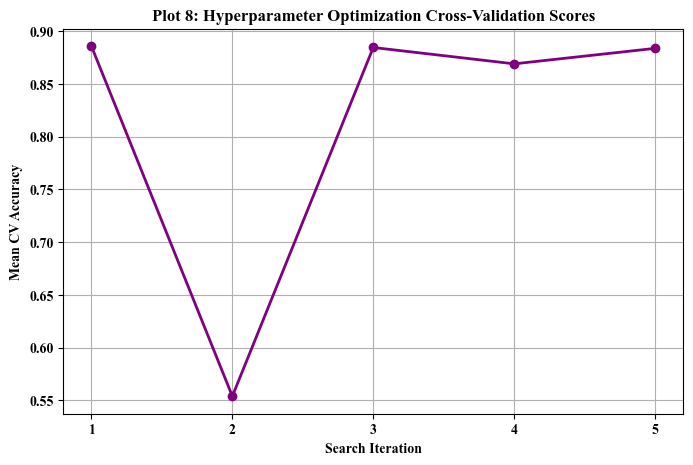

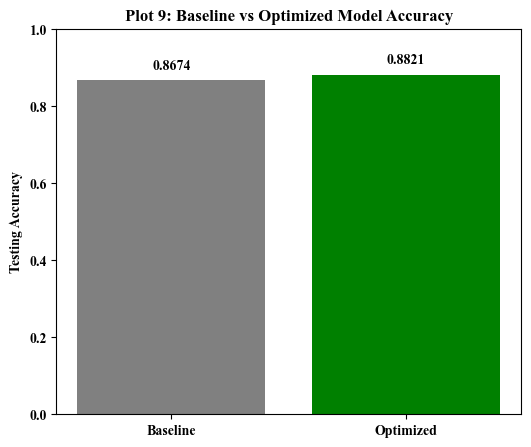


Optimized Model Final Test Metrics:
Accuracy: 0.8821 | Precision: 0.8836 | Recall: 0.8821 | F1-Score: 0.8824


In [11]:
# Retrain model with best hyperparameters (Extracted from Random Search)[cite: 1]
best_model = random_search_result.best_estimator_

# Generate predictions with the optimized model
y_pred_opt = best_model.predict(X_test)
if len(y_pred_opt.shape) > 1 and y_pred_opt.shape[1] > 1:
    y_pred_opt = np.argmax(y_pred_opt, axis=1)

# Evaluate Optimized Model[cite: 1]
acc_opt = accuracy_score(y_test_raw, y_pred_opt)
prec_opt = precision_score(y_test_raw, y_pred_opt, average='weighted')
rec_opt = recall_score(y_test_raw, y_pred_opt, average='weighted')
f1_opt = f1_score(y_test_raw, y_pred_opt, average='weighted')

# Plot 8: Hyperparameter Search Results (CV Scores across iterations)
cv_scores = random_search_result.cv_results_['mean_test_score']
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cv_scores)+1), cv_scores, marker='o', linestyle='-', color='purple', linewidth=2)
plt.title('Plot 8: Hyperparameter Optimization Cross-Validation Scores', fontweight='bold')
plt.xlabel('Search Iteration', fontweight='bold')
plt.ylabel('Mean CV Accuracy', fontweight='bold')
plt.xticks(range(1, len(cv_scores)+1), fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid(True)
plt.savefig('plot8_hyperopt_results.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

# Plot 9: Best Model Accuracy Comparison
models = ['Baseline', 'Optimized']
accuracies = [acc, acc_opt]
plt.figure(figsize=(6, 5))
bars = plt.bar(models, accuracies, color=['gray', 'green'])
plt.title('Plot 9: Baseline vs Optimized Model Accuracy', fontweight='bold')
plt.ylabel('Testing Accuracy', fontweight='bold')
plt.ylim(0, 1.0)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
# Annotate bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
plt.savefig('plot9_accuracy_comparison.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

print("\nOptimized Model Final Test Metrics:")
print(f"Accuracy: {acc_opt:.4f} | Precision: {prec_opt:.4f} | Recall: {rec_opt:.4f} | F1-Score: {f1_opt:.4f}")